In [1]:
# Fardeen Wieliams 
# 13770160
# This notebook is used for data analysis regarding the outcomes of the simulator

In [2]:
import matplotlib.pyplot as plt
from pathlib import Path

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")

In [3]:
import pandas as pd

primary = pd.read_csv("results_trace_driven/summary_primary.csv")
sensitivity = pd.read_csv("results_trace_driven/summary_sensitivity.csv")
baseline_schedule = pd.read_csv("results_trace_driven/schedule_baseline.csv")
green_schedule = pd.read_csv("results_trace_driven/schedule_green_aware.csv")
runtime_profile = pd.read_csv("results_trace_driven/runtime_profile.csv")

**Primary Comparison: Baseline vs Green-Aware**

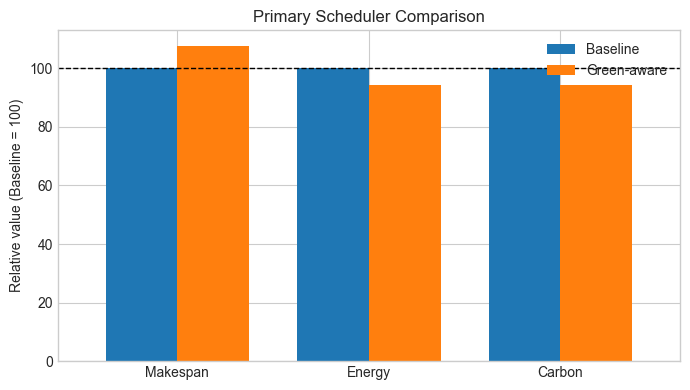

In [4]:
metrics = {
    "Makespan": "makespan_min",
    "Energy": "total_energy_kwh",
    "Carbon": "total_carbon_g",
}

plot_df = primary.set_index("scheduler")[list(metrics.values())].rename(columns={v: k for k, v in metrics.items()})

# Normalize baseline to 100
relative_df = plot_df.div(plot_df.loc["baseline"]) * 100
relative_df = relative_df.rename(index={"baseline": "Baseline", "green_aware": "Green-aware"})

ax = relative_df.T.plot(kind="bar", figsize=(7, 4), width=0.75)
ax.axhline(100, color="black", linewidth=1, linestyle="--")
ax.set_ylabel("Relative value (Baseline = 100)")
ax.set_xlabel("")
ax.set_title("Primary Scheduler Comparison")
ax.legend(title="")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(FIGURES / "primary_comparison_relative.pdf", bbox_inches="tight")
plt.show()

***Trade-Off Scatter Plot***

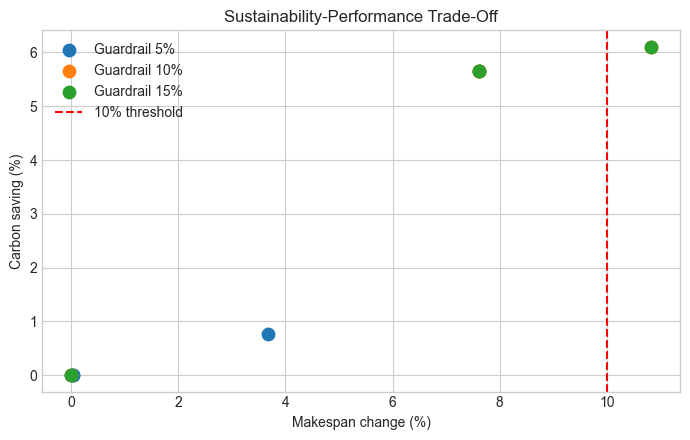

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for guardrail, group in sensitivity.groupby("guardrail"):
    ax.scatter(
        group["makespan_change_percent"],
        group["carbon_saving_percent"],
        s=80,
        label=f"Guardrail {int(guardrail * 100)}%"
    )

ax.axvline(10, color="red", linestyle="--", linewidth=1.5, label="10% threshold")

ax.set_xlabel("Makespan change (%)")
ax.set_ylabel("Carbon saving (%)")
ax.set_title("Sustainability-Performance Trade-Off")
ax.legend()
plt.tight_layout()

plt.savefig(FIGURES / "tradeoff_carbon_vs_makespan.pdf", bbox_inches="tight")
plt.show()

**Energy Saving vs Makespan Plot**

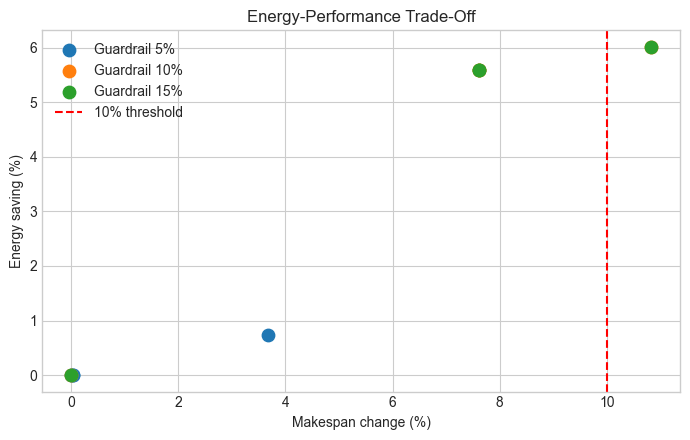

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for guardrail, group in sensitivity.groupby("guardrail"):
    ax.scatter(
        group["makespan_change_percent"],
        group["energy_saving_percent"],
        s=80,
        label=f"Guardrail {int(guardrail * 100)}%"
    )

ax.axvline(10, color="red", linestyle="--", linewidth=1.5, label="10% threshold")

ax.set_xlabel("Makespan change (%)")
ax.set_ylabel("Energy saving (%)")
ax.set_title("Energy-Performance Trade-Off")
ax.legend()
plt.tight_layout()

plt.savefig(FIGURES / "tradeoff_energy_vs_makespan.pdf", bbox_inches="tight")
plt.show()

**Runtime Profile Plot**

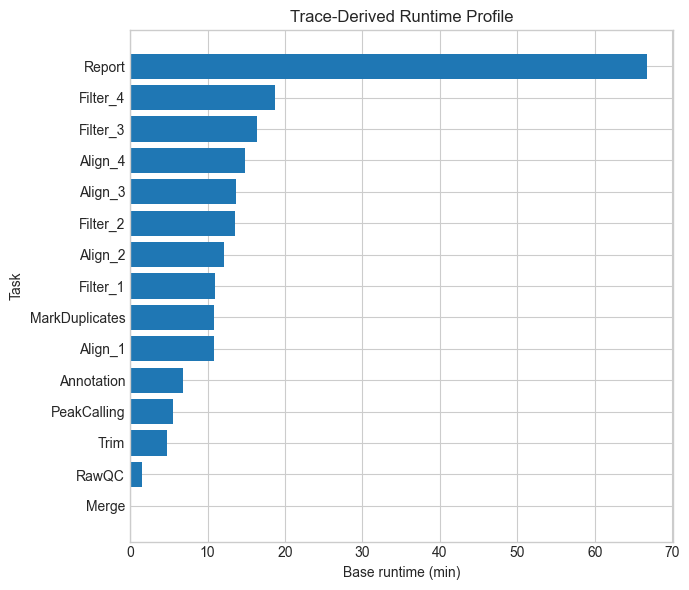

In [7]:
runtime_sorted = runtime_profile.sort_values("base_runtime_min", ascending=True)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(runtime_sorted["task"], runtime_sorted["base_runtime_min"])

ax.set_xlabel("Base runtime (min)")
ax.set_ylabel("Task")
ax.set_title("Trace-Derived Runtime Profile")
plt.tight_layout()

plt.savefig(FIGURES / "runtime_profile.pdf", bbox_inches="tight")
plt.show()

**Gantt Chart: Baseline**

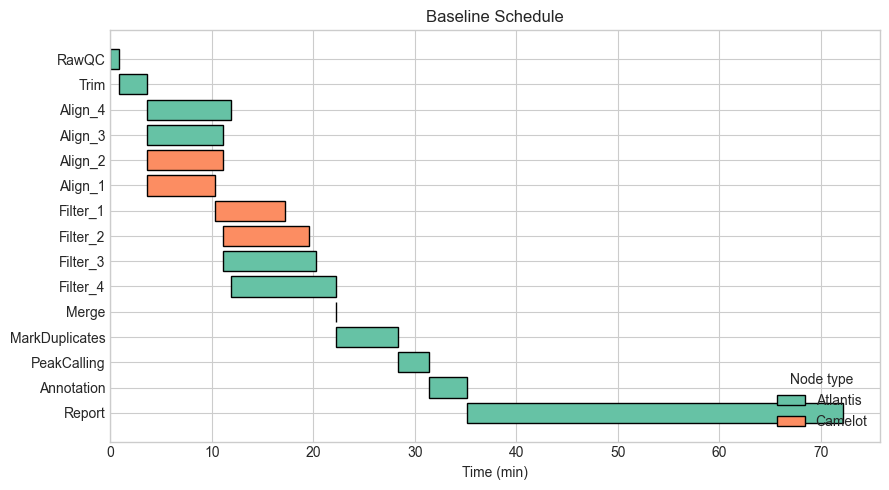

In [8]:
def plot_gantt(schedule, title, filename):
    schedule = schedule.sort_values("start_min").copy()
    
    fig, ax = plt.subplots(figsize=(9, 5))
    
    node_types = schedule["node_type"].unique()
    colors = dict(zip(node_types, plt.cm.Set2(range(len(node_types)))))
    
    y_labels = schedule["task"].tolist()
    y_positions = range(len(schedule))
    
    for y, (_, row) in zip(y_positions, schedule.iterrows()):
        ax.barh(
            y,
            row["runtime_min"],
            left=row["start_min"],
            color=colors[row["node_type"]],
            edgecolor="black",
            label=row["node_type"]
        )
    
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    
    ax.set_yticks(list(y_positions))
    ax.set_yticklabels(y_labels)
    ax.set_xlabel("Time (min)")
    ax.set_title(title)
    ax.legend(unique.values(), unique.keys(), title="Node type", loc="lower right")
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.savefig(FIGURES / filename, bbox_inches="tight")
    plt.show()

plot_gantt(
    baseline_schedule,
    "Baseline Schedule",
    "gantt_baseline.pdf"
)

**Gantt Chart: Green-Aware**

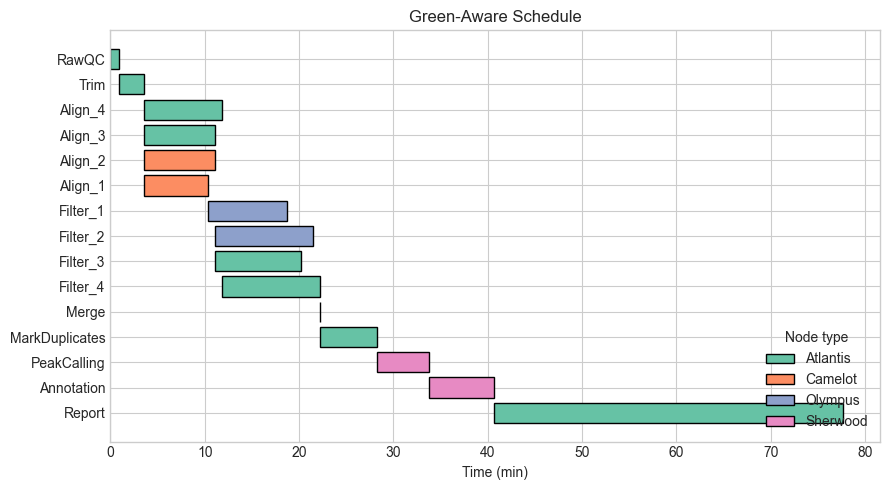

In [9]:
plot_gantt(
    green_schedule,
    "Green-Aware Schedule",
    "gantt_green_aware.pdf"
)

**Node-Type Runtime Usage**

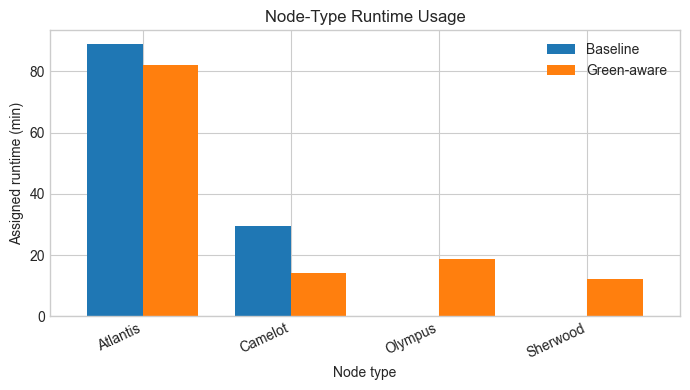

In [10]:
combined_schedule = pd.concat([baseline_schedule, green_schedule], ignore_index=True)

usage = (
    combined_schedule
    .groupby(["scheduler", "node_type"])["runtime_min"]
    .sum()
    .reset_index()
)

usage_pivot = usage.pivot(index="node_type", columns="scheduler", values="runtime_min").fillna(0)
usage_pivot = usage_pivot.rename(columns={"baseline": "Baseline", "green_aware": "Green-aware"})

ax = usage_pivot.plot(kind="bar", figsize=(7, 4), width=0.75)

ax.set_xlabel("Node type")
ax.set_ylabel("Assigned runtime (min)")
ax.set_title("Node-Type Runtime Usage")
ax.legend(title="")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(FIGURES / "node_type_runtime_usage.pdf", bbox_inches="tight")
plt.show()

In [11]:
import seaborn as sns

def weight_label(row):
    return f"({row['weight_time']:.1f}, {row['weight_energy']:.1f}, {row['weight_carbon']:.1f})"

sensitivity["weight_config"] = sensitivity.apply(weight_label, axis=1)
sensitivity["guardrail_label"] = (sensitivity["guardrail"] * 100).astype(int).astype(str) + "%"

**Carbonsaving heatmap**

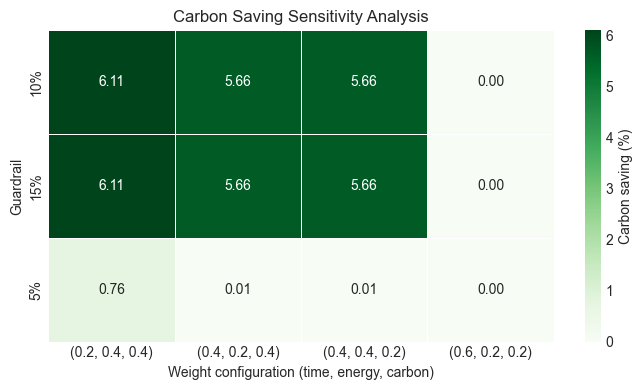

In [12]:
carbon_heatmap = sensitivity.pivot_table(
    index="guardrail_label",
    columns="weight_config",
    values="carbon_saving_percent"
)

fig, ax = plt.subplots(figsize=(7, 4))

sns.heatmap(
    carbon_heatmap,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    linewidths=0.5,
    cbar_kws={"label": "Carbon saving (%)"},
    ax=ax
)

ax.set_xlabel("Weight configuration (time, energy, carbon)")
ax.set_ylabel("Guardrail")
ax.set_title("Carbon Saving Sensitivity Analysis")

plt.tight_layout()
plt.savefig(FIGURES / "heatmap_carbon_saving.pdf", bbox_inches="tight")
plt.show()

**Makespan change heatmap**

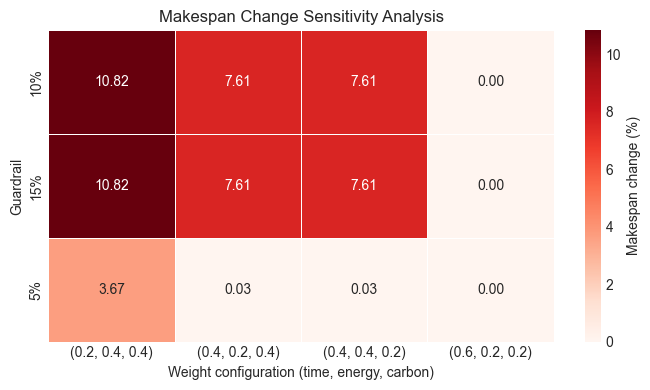

In [13]:
makespan_heatmap = sensitivity.pivot_table(
    index="guardrail_label",
    columns="weight_config",
    values="makespan_change_percent"
)

fig, ax = plt.subplots(figsize=(7, 4))

sns.heatmap(
    makespan_heatmap,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    linewidths=0.5,
    cbar_kws={"label": "Makespan change (%)"},
    ax=ax
)

ax.set_xlabel("Weight configuration (time, energy, carbon)")
ax.set_ylabel("Guardrail")
ax.set_title("Makespan Change Sensitivity Analysis")

plt.tight_layout()
plt.savefig(FIGURES / "heatmap_makespan_change.pdf", bbox_inches="tight")
plt.show()

**Energy change heatmap**

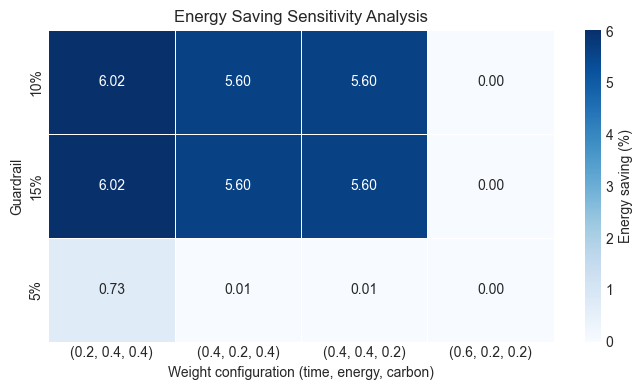

In [14]:
energy_heatmap = sensitivity.pivot_table(
    index="guardrail_label",
    columns="weight_config",
    values="energy_saving_percent"
)

fig, ax = plt.subplots(figsize=(7, 4))

sns.heatmap(
    energy_heatmap,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Energy saving (%)"},
    ax=ax
)

ax.set_xlabel("Weight configuration (time, energy, carbon)")
ax.set_ylabel("Guardrail")
ax.set_title("Energy Saving Sensitivity Analysis")

plt.tight_layout()
plt.savefig(FIGURES / "heatmap_energy_saving.pdf", bbox_inches="tight")
plt.show()

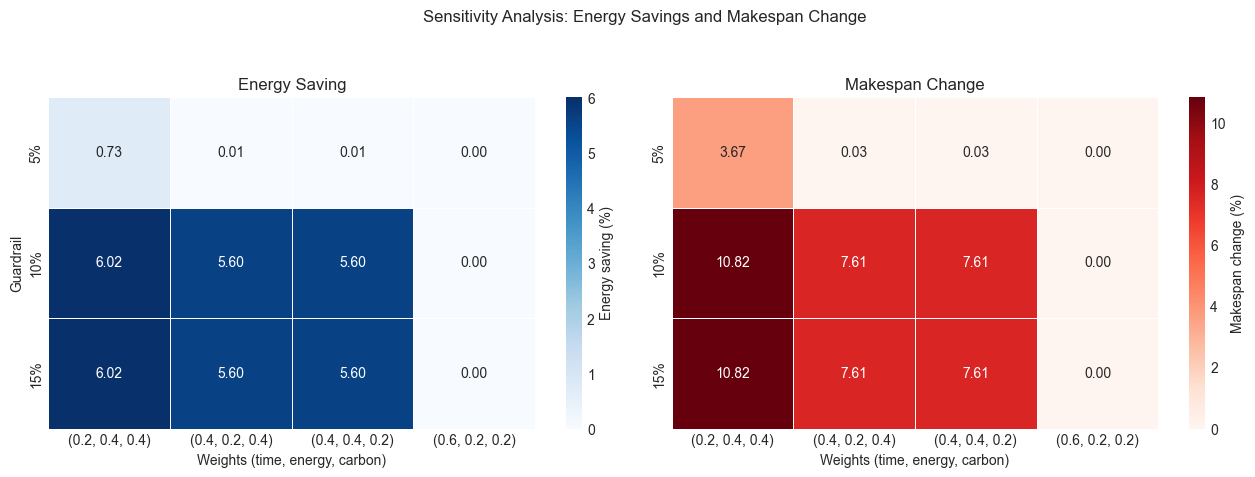

In [15]:
energy_heatmap = sensitivity.pivot_table(
    index="guardrail_label",
    columns="weight_config",
    values="energy_saving_percent"
)

makespan_heatmap = sensitivity.pivot_table(
    index="guardrail_label",
    columns="weight_config",
    values="makespan_change_percent"
)

# Keep guardrails in logical order
guardrail_order = ["5%", "10%", "15%"]
energy_heatmap = energy_heatmap.reindex(guardrail_order)
makespan_heatmap = makespan_heatmap.reindex(guardrail_order)

# Plot side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.heatmap(
    energy_heatmap,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Energy saving (%)"},
    ax=axes[0]
)

axes[0].set_title("Energy Saving")
axes[0].set_xlabel("Weights (time, energy, carbon)")
axes[0].set_ylabel("Guardrail")

sns.heatmap(
    makespan_heatmap,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    linewidths=0.5,
    cbar_kws={"label": "Makespan change (%)"},
    ax=axes[1]
)

axes[1].set_title("Makespan Change")
axes[1].set_xlabel("Weights (time, energy, carbon)")
axes[1].set_ylabel("")

plt.suptitle("Sensitivity Analysis: Energy Savings and Makespan Change", y=1.05)
plt.tight_layout()

plt.savefig(FIGURES / "heatmap_energy_makespan_sensitivity.pdf", bbox_inches="tight")
plt.show()